# LoRa MIMO DSP Chain — Step-by-Step Walkthrough

Receive-only ASIC path between four SX1257 RF front-ends and an SX1302 LoRa baseband processor. The notebook models Mode 1 (`NT=1, NR=4`) MRC plus the Mode 3 passthrough baseline.

**Hardware stages modeled here:**
1. SX1257 ΣΔ ADC source model
2. Programmable ΣΔ decimator: 32 MS/s -> 125 kS/s-1 MS/s, int8 IQ
3. Schmidl-Cox preamble detector for `sc_lock` and `timing_ref`
4. Three-pass FFT preamble acquisition: RCTSL fractional CFO, integer bin, channel estimate
5. PicoRV32 weight computation, quantised to Q1.15
6. MRC combiner, with Mode 3 bypass MUX baseline
7. 3rd-order ΣΔ re-modulator back to 32 MS/s
8. SX1302-style dechirp + FFT demodulation


In [292]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('../..').resolve()))

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

from sim.models.lora     import upchirp, modulate, demodulate
from sim.models.channel  import rayleigh_coefficients, apply_channel
from sim.models.sync     import SchmidlCoxDetector, resolve_sync
from sim.models.receiver import estimate_channel, _cfo_frac_rctsl, compute_weights, mrc_combine
from sim.models.converter import SigmaDeltaRemodulator

rng = np.random.default_rng(41)
np.random.seed(41)  # models use np.random directly

# --- Parameters ---
SF  = 12         # Spreading Factor
M   = 2 ** SF   # chips per symbol
NR  = 4         # receive antennas
NT  = 1         # Mode 1: one transmitted LoRa stream, MRC output

ADC_FS = 32e6   # SX1257 1-bit ΣΔ ADC rate
BW  = 1000e3     # LoRa bandwidth / decimated complex sample rate
DECIM_TABLE = {
    1000e3: {'cfg': 0x00, 'ratio': 32},
    500e3:  {'cfg': 0x01, 'ratio': 64},
    250e3:  {'cfg': 0x02, 'ratio': 128},
    125e3:  {'cfg': 0x03, 'ratio': 256},
}
DECIM = DECIM_TABLE[BW]
DECIM_CFG = DECIM['cfg']
DECIM_RATIO = DECIM['ratio']
Fs = BW
OSR = DECIM_RATIO
BIN_HZ = BW / M

SNR_DB = -15.0
N0  = 10 ** (-SNR_DB / 10)
N_PREAMBLE = 8
SC_THRESHOLD = 0.90

print(f'SF={SF}  M={M}  NR={NR}  NT={NT}  SNR={SNR_DB} dB  N0={N0:.4f}')
print(f'ADC_FS={ADC_FS/1e6:.0f} MS/s  DECIM_CFG=0x{DECIM_CFG:02X}  R={DECIM_RATIO}x')
print(f'BW/Fs={BW/1e3:.0f} kHz  Bin width={BIN_HZ:.2f} Hz  Symbol={M/Fs*1e3:.3f} ms')


SF=12  M=4096  NR=4  NT=1  SNR=-15.0 dB  N0=31.6228
ADC_FS=32 MS/s  DECIM_CFG=0x00  R=32x
BW/Fs=1000 kHz  Bin width=244.14 Hz  Symbol=4.096 ms


## Stage 1 — Modulation
Pick a random symbol `b` and generate the CSS chirp.

Transmitted symbol: b_tx = 2720


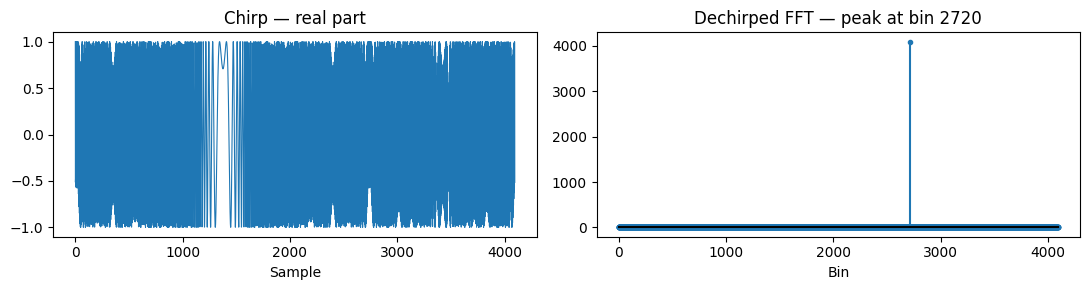

In [293]:
b_tx = int(rng.integers(0, M))
s = modulate(b_tx, M)

print(f'Transmitted symbol: b_tx = {b_tx}')

fig, axes = plt.subplots(1, 2, figsize=(11, 3))

n = np.arange(M)
axes[0].plot(n, s.real, lw=0.8)
axes[0].set_title('Chirp — real part')
axes[0].set_xlabel('Sample')

dechirped_ref = s * np.exp(-1j * np.pi * n**2 / M)
fft_ref = np.abs(np.fft.fft(dechirped_ref))
axes[1].stem(fft_ref, markerfmt='C0.', linefmt='C0-', basefmt='k-')
axes[1].set_title(f'Dechirped FFT — peak at bin {b_tx}')
axes[1].set_xlabel('Bin')

plt.tight_layout()
plt.show()

### Effect of dechirping
Multiply the chirp by the conjugate reference downchirp `exp(-j·π·n²/M)`. For an ideal LoRa symbol this cancels the quadratic sweep, leaving a nearly constant-bin complex tone. The FFT can then localise the symbol as one strong peak.

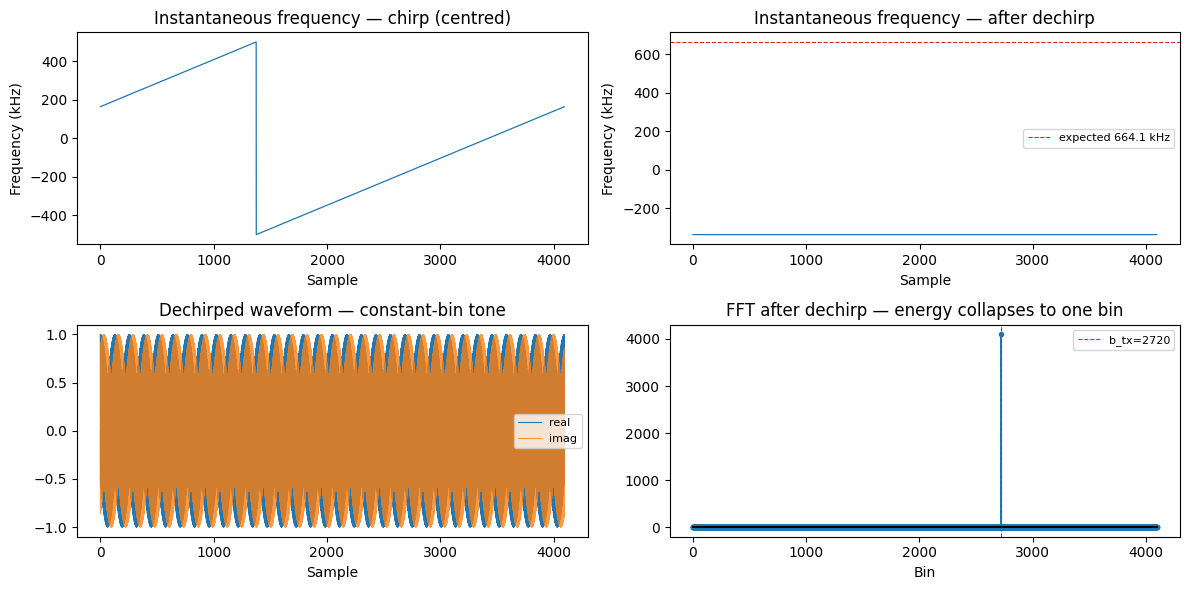

Expected constant-bin frequency after dechirp: 664.062 kHz
FFT peak bin after dechirp: 2720


In [294]:
s_centered = s * np.exp(-1j * np.pi * n)
downchirp = np.exp(-1j * np.pi * n**2 / M)
dechirped = s * downchirp

inst_freq_chirp = np.angle(s_centered[1:] * np.conj(s_centered[:-1])) / (2 * np.pi) * Fs
inst_freq_dechirped = np.angle(dechirped[1:] * np.conj(dechirped[:-1])) / (2 * np.pi) * Fs
expected_bin_freq = b_tx * Fs / M
fft_dechirped = np.abs(np.fft.fft(dechirped))

fig, axes = plt.subplots(2, 2, figsize=(12, 6))

axes[0, 0].plot(n[:-1], inst_freq_chirp / 1e3, lw=0.9)
axes[0, 0].set_title('Instantaneous frequency — chirp (centred)')
axes[0, 0].set_xlabel('Sample')
axes[0, 0].set_ylabel('Frequency (kHz)')

axes[0, 1].plot(n[:-1], inst_freq_dechirped / 1e3, lw=0.9)
axes[0, 1].axhline(expected_bin_freq / 1e3, color='C3', lw=0.8, linestyle='--',
                   label=f'expected {expected_bin_freq/1e3:.1f} kHz')
axes[0, 1].set_title('Instantaneous frequency — after dechirp')
axes[0, 1].set_xlabel('Sample')
axes[0, 1].set_ylabel('Frequency (kHz)')
axes[0, 1].legend(fontsize=8)

axes[1, 0].plot(n, dechirped.real, lw=0.8, label='real')
axes[1, 0].plot(n, dechirped.imag, lw=0.8, label='imag', alpha=0.8)
axes[1, 0].set_title('Dechirped waveform — constant-bin tone')
axes[1, 0].set_xlabel('Sample')
axes[1, 0].legend(fontsize=8)

axes[1, 1].stem(fft_dechirped, markerfmt='C0.', linefmt='C0-', basefmt='k-')
axes[1, 1].axvline(b_tx, color='C3', lw=0.8, linestyle='--', label=f'b_tx={b_tx}')
axes[1, 1].set_title('FFT after dechirp — energy collapses to one bin')
axes[1, 1].set_xlabel('Bin')
axes[1, 1].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f'Expected constant-bin frequency after dechirp: {expected_bin_freq/1e3:.3f} kHz')
print(f'FFT peak bin after dechirp: {int(np.argmax(fft_dechirped))}')


SF=12  M=4096  upsample=8  nfft=512  visible freq bins ≈ 64


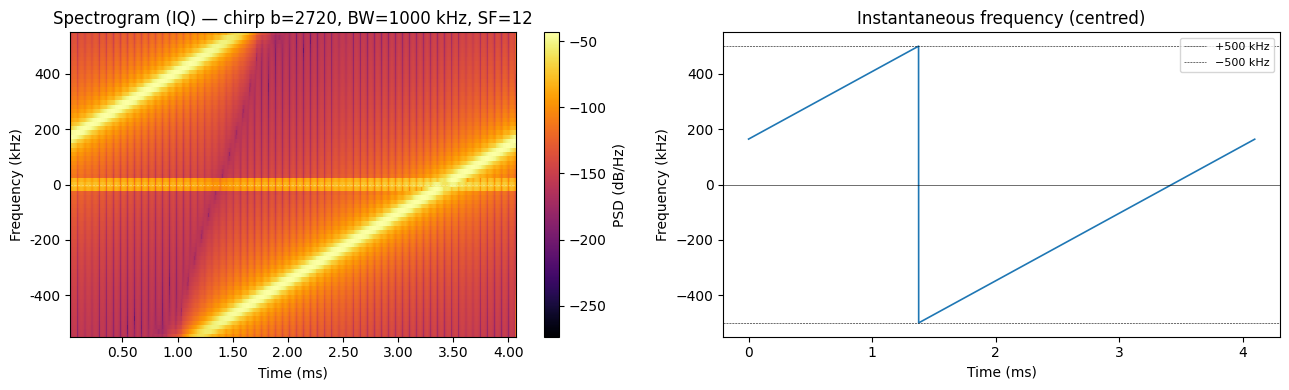

In [295]:
from scipy.signal import resample_poly as _resample
from scipy.signal import spectrogram  as _spectrogram

ms  = lambda x, _: f'{x*1e3:.2f}'
khz = lambda y, _: f'{y/1e3:.0f}'

def plot_specgram(ax, sig, nfft=None, noverlap=None, fs=Fs, upsample=8, **kwargs):
    """
    Spectrogram for complex IQ, centred at DC.

    The LoRa chirp formula exp(j·π·(2b·n+n²)/M) has instantaneous frequency
    in [0, BW].  Multiplying by exp(-j·π·n) before upsampling shifts it to
    [−BW/2, +BW/2].  The shift MUST happen before resample_poly because the
    polyphase LPF cuts at BW/2 (original Nyquist); any content above that is
    lost if it arrives after upsampling.

    nfft defaults to upsample × √M — the largest window that keeps each
    chirp sweep to ≤1 bin, giving √M visible frequency bins across the BW.
    Visible bins: SF7→11, SF9→22, SF12→64.
    """
    # Centre at DC before upsampling so the polyphase LPF passes everything
    n_orig = np.arange(len(sig))
    sig = sig * np.exp(-1j * np.pi * n_orig)

    if upsample > 1:
        sig_up = _resample(sig.real, upsample, 1) + 1j * _resample(sig.imag, upsample, 1)
        fs_up  = fs * upsample
    else:
        sig_up, fs_up = sig, fs

    if nfft is None:
        nfft = max(16, int(upsample * M ** 0.5))   # M is the global chips-per-symbol

    if noverlap is None:
        noverlap = nfft * 7 // 8

    f, t, Sxx = _spectrogram(
        sig_up, fs=fs_up, nperseg=nfft, noverlap=noverlap,
        return_onesided=False, scaling='density', window='hann'
    )
    f   = np.fft.fftshift(f)
    Sxx = np.fft.fftshift(Sxx, axes=0)
    Sxx_db = 10 * np.log10(np.abs(Sxx) + 1e-30)

    kw = dict(cmap='inferno', shading='auto')
    kw.update(kwargs)
    im = ax.pcolormesh(t, f, Sxx_db, **kw)

    # 10% padding so the ±BW/2 chirp edge doesn't touch the axis boundary
    ax.set_ylim(-fs / 2 * 1.1, fs / 2 * 1.1)
    ax.axhline(0, color='white', lw=0.5, linestyle='--', alpha=0.4)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(ms))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(khz))
    ax.set_xlabel('Time (ms)')
    ax.set_ylabel('Frequency (kHz)')
    return im

nfft_used = max(16, int(8 * M ** 0.5))
print(f'SF={SF}  M={M}  upsample=8  nfft={nfft_used}  visible freq bins ≈ {nfft_used // 8}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

im = plot_specgram(axes[0], s, fs=Fs)
axes[0].set_title(f'Spectrogram (IQ) — chirp b={b_tx}, BW={BW/1e3:.0f} kHz, SF={SF}')
fig.colorbar(im, ax=axes[0], label='PSD (dB/Hz)')

s_centered = s * np.exp(-1j * np.pi * np.arange(len(s)))
inst_freq = np.angle(s_centered[1:] * np.conj(s_centered[:-1])) / (2 * np.pi) * Fs
axes[1].plot(np.arange(M - 1) / Fs * 1e3, inst_freq / 1e3, lw=1.2)
axes[1].set_title('Instantaneous frequency (centred)')
axes[1].set_xlabel('Time (ms)')
axes[1].set_ylabel('Frequency (kHz)')
axes[1].axhline( BW/2e3, color='k', lw=0.4, linestyle='--', label=f'+{BW/2e3:.0f} kHz')
axes[1].axhline(-BW/2e3, color='k', lw=0.4, linestyle='--', label=f'−{BW/2e3:.0f} kHz')
axes[1].axhline(0, color='k', lw=0.4)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


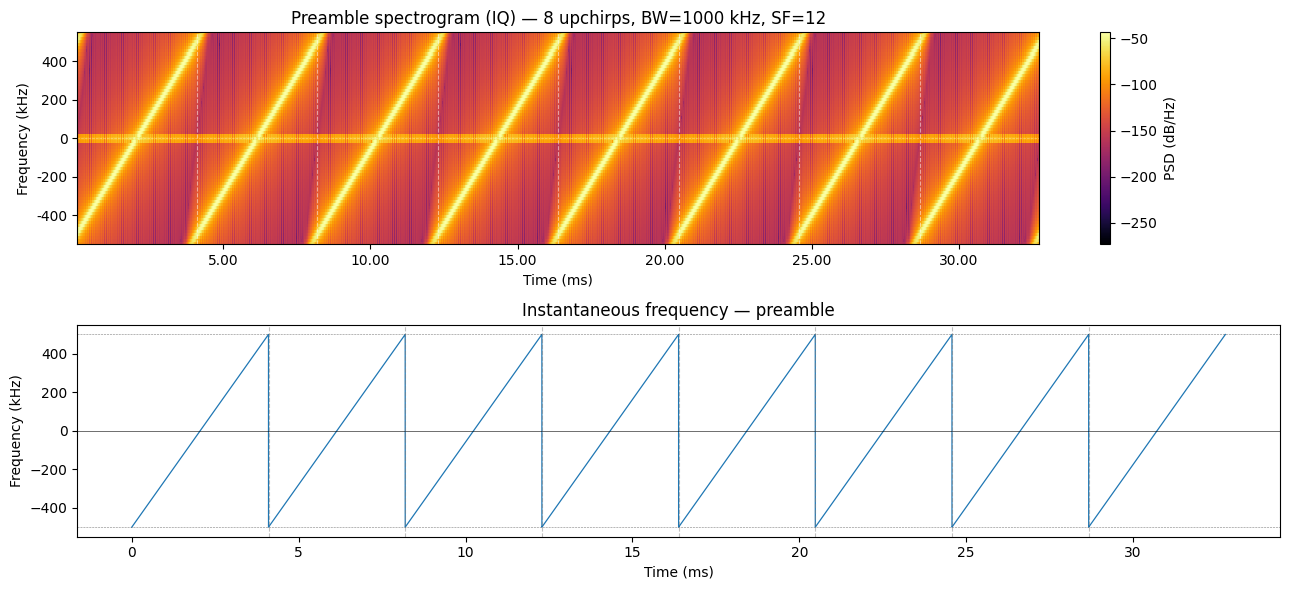

Symbol duration:   4.096 ms
Preamble duration: 32.768 ms


In [296]:

preamble = np.tile(upchirp(M), N_PREAMBLE)  # 8 × M chips

fig, axes = plt.subplots(2, 1, figsize=(13, 6))

im = plot_specgram(axes[0], preamble, fs=Fs)   # auto nfft = upsample × √M
# Mark symbol boundaries
for k in range(1, N_PREAMBLE):
    axes[0].axvline(k * M / Fs, color='white', lw=0.8, linestyle='--', alpha=0.5)
axes[0].set_title(f'Preamble spectrogram (IQ) — {N_PREAMBLE} upchirps, BW={BW/1e3:.0f} kHz, SF={SF}')
fig.colorbar(im, ax=axes[0], label='PSD (dB/Hz)')

preamble_centered = preamble * np.exp(-1j * np.pi * np.arange(len(preamble)))
t_pre          = np.arange(len(preamble) - 1) / Fs * 1e3
inst_freq_pre  = np.angle(preamble_centered[1:] * np.conj(preamble_centered[:-1])) / (2 * np.pi) * Fs
axes[1].plot(t_pre, inst_freq_pre / 1e3, lw=0.9)
axes[1].set_title('Instantaneous frequency — preamble')
axes[1].set_xlabel('Time (ms)')
axes[1].set_ylabel('Frequency (kHz)')
axes[1].axhline( BW/2e3, color='k', lw=0.4, linestyle='--', alpha=0.5)
axes[1].axhline(-BW/2e3, color='k', lw=0.4, linestyle='--', alpha=0.5)
axes[1].axhline(0, color='k', lw=0.4)
for k in range(1, N_PREAMBLE):
    axes[1].axvline(k * M / Fs * 1e3, color='grey', lw=0.8, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

symbol_duration_ms = M / Fs * 1e3
print(f'Symbol duration:   {symbol_duration_ms:.3f} ms')
print(f'Preamble duration: {N_PREAMBLE * symbol_duration_ms:.3f} ms')


## Stage 2 — Channel
Generate NR independent Rayleigh fading coefficients and pass the chirp through each.

In [297]:
h_true = rayleigh_coefficients(NR, pll_phase_random=True)
rx_payload = np.stack([apply_channel(s, h_true[j], N0) for j in range(NR)])

print(f'rx_payload shape: {rx_payload.shape}  (NR × M)\n')
print(f'{"Ant":>3}  {"h":>20}  {"|h|":>6}  {"∠h (°)":>9}')
print('-' * 44)
for j, hj in enumerate(h_true):
    print(f'  {j}  {hj:>20.4f}  {abs(hj):>6.4f}  {np.degrees(np.angle(hj)):>+9.1f}°')

rx_payload shape: (4, 4096)  (NR × M)

Ant                     h     |h|     ∠h (°)
--------------------------------------------
  0        0.2541+0.3646j  0.4444      +55.1°
  1       -0.7045-0.2241j  0.7392     -162.4°
  2       -0.1691-0.1208j  0.2078     -144.5°
  3        0.2418+0.8255j  0.8602      +73.7°


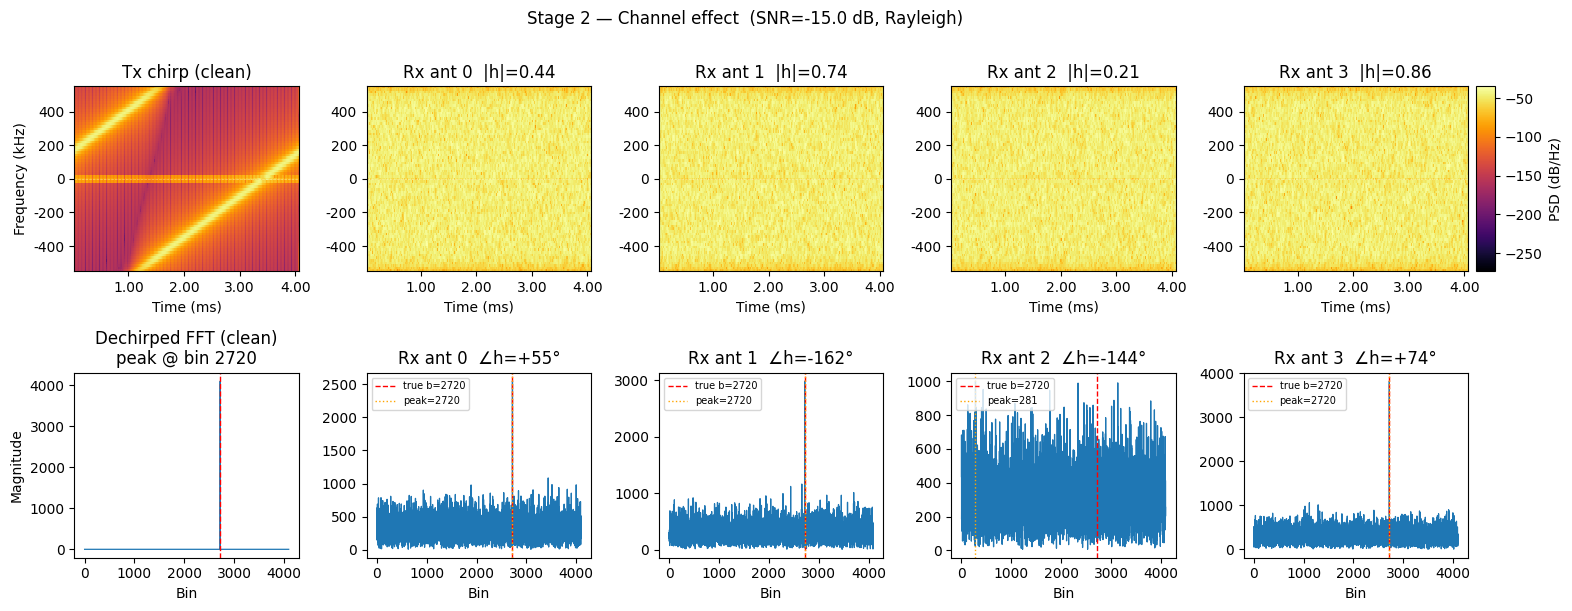

In [298]:

fig, axes = plt.subplots(2, NR + 1, figsize=(15, 6))
n = np.arange(M)

def dechirp_fft(sig):
    return np.abs(np.fft.fft(sig * np.exp(-1j * np.pi * n**2 / M)))

# Row 0: spectrograms — clean chirp then each antenna, shared colour scale
ims = []
ims.append(plot_specgram(axes[0, 0], s, fs=Fs))
axes[0, 0].set_title('Tx chirp (clean)')

for j in range(NR):
    ims.append(plot_specgram(axes[0, j + 1], rx_payload[j], fs=Fs))
    axes[0, j + 1].set_title(f'Rx ant {j}  |h|={abs(h_true[j]):.2f}')
    axes[0, j + 1].set_ylabel('')

# Normalise colour scale across all spectrograms
clims  = [im.get_clim() for im in ims]
vmin_s = min(c[0] for c in clims)
vmax_s = max(c[1] for c in clims)
for im in ims:
    im.set_clim(vmin_s, vmax_s)
# Row 1: dechirped FFT — clean chirp then each noisy antenna
fft_clean = dechirp_fft(s)
axes[1, 0].plot(fft_clean, lw=0.9)
axes[1, 0].axvline(b_tx, color='red', lw=1, linestyle='--')
axes[1, 0].set_title(f'Dechirped FFT (clean)\npeak @ bin {b_tx}')
axes[1, 0].set_ylabel('Magnitude')
axes[1, 0].set_xlabel('Bin')

for j in range(NR):
    fft_rx = dechirp_fft(rx_payload[j])
    peak   = np.argmax(fft_rx)
    axes[1, j + 1].plot(fft_rx, lw=0.9)
    axes[1, j + 1].axvline(b_tx, color='red', lw=1, linestyle='--', label=f'true b={b_tx}')
    axes[1, j + 1].axvline(peak, color='orange', lw=1, linestyle=':', label=f'peak={peak}')
    axes[1, j + 1].set_title(f'Rx ant {j}  ∠h={np.degrees(np.angle(h_true[j])):+.0f}°')
    axes[1, j + 1].legend(fontsize=7)
    axes[1, j + 1].set_xlabel('Bin')

plt.suptitle(f'Stage 2 — Channel effect  (SNR={SNR_DB} dB, Rayleigh)', y=1.01)
plt.tight_layout()
# Add colorbar after tight_layout so axis positions are final
pos = axes[0, -1].get_position()
cax = fig.add_axes([pos.x1 + 0.005, pos.y0, 0.013, pos.height])
fig.colorbar(ims[-1], cax=cax, label='PSD (dB/Hz)')
plt.show()


## Stage 2 — ΣΔ Decimator

The SX1257 supplies 1-bit I/Q streams at 32 MS/s. Hardware CIC + FIR compensation decimates by `R` so downstream blocks see exactly `M = 2^SF` samples per LoRa symbol. This notebook starts from complex baseband samples, then applies the same decimator-facing contract: automatic gain scaling and signed int8 I/Q outputs gated by `iq_valid`.


DECIM_CFG table:
  0x03: BW= 125 kHz  R=256x  Fs=  125.0 kS/s  planning LSB= 122 Hz
  0x02: BW= 250 kHz  R=128x  Fs=  250.0 kS/s  planning LSB= 244 Hz
  0x01: BW= 500 kHz  R= 64x  Fs=  500.0 kS/s  planning LSB= 488 Hz
  0x00: BW=1000 kHz  R= 32x  Fs= 1000.0 kS/s  planning LSB= 976 Hz


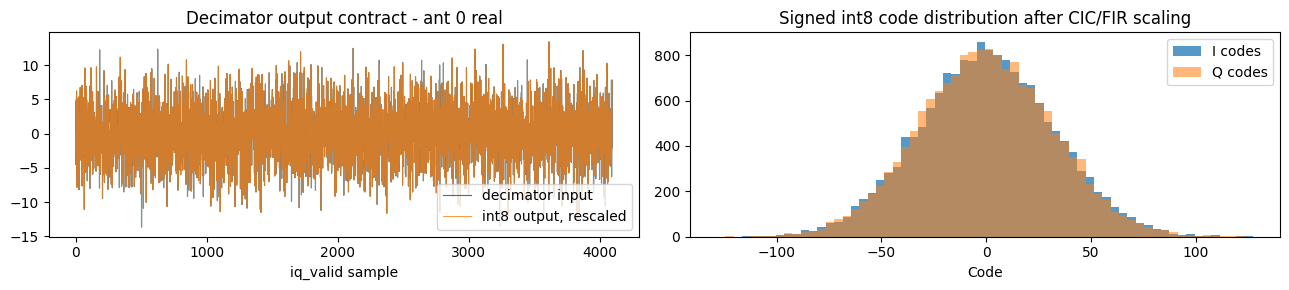

Stage 2 output: rx_payload shape=(4, 4096), dtype=float model of int8 codes
Applied automatic decimator scale: 7.98 codes/unit
Code range I/Q: [-113, 127] / [-123, 122]


In [299]:
from sim.models.fixed import quantize

DECIM_OPTIONS = [(0x03, 125e3, 256, 122), (0x02, 250e3, 128, 244), (0x01, 500e3, 64, 488), (0x00, 1000e3, 32, 976)]
print('DECIM_CFG table:')
for cfg, bw_hz, ratio, lsb_hz in DECIM_OPTIONS:
    print(f'  0x{cfg:02X}: BW={bw_hz/1e3:4.0f} kHz  R={ratio:3d}x  Fs={ADC_FS/ratio/1e3:7.1f} kS/s  planning LSB={lsb_hz:4.0f} Hz')

def decimate_to_int8(x):
    """Model decimator output scaling: complex float -> int8 IQ codes -> scaled float."""
    peak = max(np.max(np.abs(x.real)), np.max(np.abs(x.imag)), 1e-12)
    scale = 127.0 / peak
    i_codes = quantize(x.real * scale, 8, signed=True, round_mode='round')
    q_codes = quantize(x.imag * scale, 8, signed=True, round_mode='round')
    codes = i_codes + 1j * q_codes
    return codes, codes / scale, scale

rx_payload_float = rx_payload
rx_decim_codes, rx_payload, decim_scale = decimate_to_int8(rx_payload_float)

fig, axes = plt.subplots(1, 2, figsize=(13, 3))
j_show = 0
axes[0].plot(rx_payload_float[j_show].real, lw=0.8, label='decimator input')
axes[0].step(range(M), rx_payload[j_show].real, lw=0.7, alpha=0.8, where='mid', label='int8 output, rescaled')
axes[0].set_title(f'Decimator output contract - ant {j_show} real')
axes[0].set_xlabel('iq_valid sample')
axes[0].legend()

axes[1].hist(rx_decim_codes.real.ravel(), bins=np.arange(-128.5, 128.5, 4), alpha=0.75, label='I codes')
axes[1].hist(rx_decim_codes.imag.ravel(), bins=np.arange(-128.5, 128.5, 4), alpha=0.55, label='Q codes')
axes[1].set_title('Signed int8 code distribution after CIC/FIR scaling')
axes[1].set_xlabel('Code')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Stage 2 output: rx_payload shape={rx_payload.shape}, dtype=float model of int8 codes')
print(f'Applied automatic decimator scale: {decim_scale:.2f} codes/unit')
print(f'Code range I/Q: [{rx_decim_codes.real.min():.0f}, {rx_decim_codes.real.max():.0f}] / '
      f'[{rx_decim_codes.imag.min():.0f}, {rx_decim_codes.imag.max():.0f}]')


### Channel estimation from a single pilot chirp
With the transmitted chirp `s` known at the receiver, the least-squares channel estimate per antenna is:

$$\hat{h}_j = \frac{s^H \, r_j}{\|s\|^2} = \frac{1}{M} \sum_n s^*[n] \, r_j[n]$$

This is a matched-filter / correlation operation. With one symbol the estimate is noisy and sensitive to CFO. Stage 4 instead uses 8 preamble symbols, RCTSL fractional CFO correction, an integer-bin FFT search, and coherent averaging.


||s||² = 4096.0  (= M = 4096)

Ant                h_true       h_hat (1 chirp)   |error|  ∠error (°)
--------------------------------------------------------------------
  0        0.2541+0.3646j        0.4062+0.4704j    0.1853        -5.9°
  1       -0.7045-0.2241j       -0.6974-0.2094j    0.0163        -0.9°
  2       -0.1691-0.1208j       -0.0894-0.0684j    0.0954        +1.9°
  3        0.2418+0.8255j        0.3238+0.8746j    0.0955        -4.0°


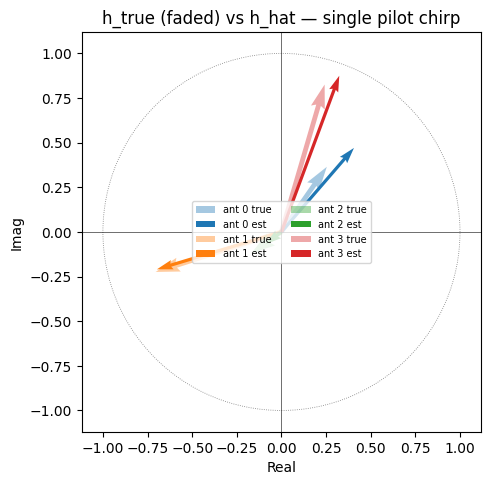

In [300]:
# LS channel estimate: correlate each received antenna with the known pilot chirp
s_norm_sq = np.dot(s.conj(), s).real  # = M (chirp is unit-amplitude)
h_hat_single = np.array([np.dot(s.conj(), rx_payload[j]) / s_norm_sq for j in range(NR)])

print(f'||s||² = {s_norm_sq:.1f}  (= M = {M})\n')
print(f'{"Ant":>3}  {"h_true":>20}  {"h_hat (1 chirp)":>20}  {"|error|":>8}  {"∠error (°)":>10}')
print('-' * 68)
for j in range(NR):
    err = h_hat_single[j] - h_true[j]
    ang_err = np.degrees(np.angle(h_hat_single[j]) - np.angle(h_true[j]))
    print(f'  {j}  {h_true[j]:>20.4f}  {h_hat_single[j]:>20.4f}  {abs(err):>8.4f}  {ang_err:>+10.1f}°')

# IQ plane: true vs estimated using quiver
fig, ax = plt.subplots(figsize=(5, 5))
for j in range(NR):
    # true — dashed style via two overlapping quiver calls
    ax.quiver(0, 0, h_true[j].real, h_true[j].imag,
              angles='xy', scale_units='xy', scale=1,
              color=f'C{j}', alpha=0.4, width=0.012, label=f'ant {j} true')
    ax.quiver(0, 0, h_hat_single[j].real, h_hat_single[j].imag,
              angles='xy', scale_units='xy', scale=1,
              color=f'C{j}', width=0.008, label=f'ant {j} est')

lim = max(np.abs(np.concatenate([h_true, h_hat_single])).max() * 1.2, 0.5)
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
circle = plt.Circle((0, 0), 1, color='grey', fill=False, lw=0.6, linestyle=':')
ax.add_patch(circle)
ax.axhline(0, color='k', lw=0.4)
ax.axvline(0, color='k', lw=0.4)
ax.set_aspect('equal')
ax.legend(fontsize=7, ncol=2)
ax.set_title('h_true (faded) vs h_hat — single pilot chirp')
ax.set_xlabel('Real')
ax.set_ylabel('Imag')
plt.tight_layout()
plt.show()

## Stage 3 — Schmidl-Cox Preamble Detector

Sliding-window autocorrelation across adjacent dechirped symbols provides `sc_lock` and a back-calculated `timing_ref`. `sc_lock` arms the capture FSM; it is not the FFT trigger. The FSM waits until a guarded window is resident in SRAM, freezes it, then asserts `capture_window_ready` for Stage 4. The SC phase is displayed as a diagnostic only; Stage 4 RCTSL is the source of `eps_sub`.


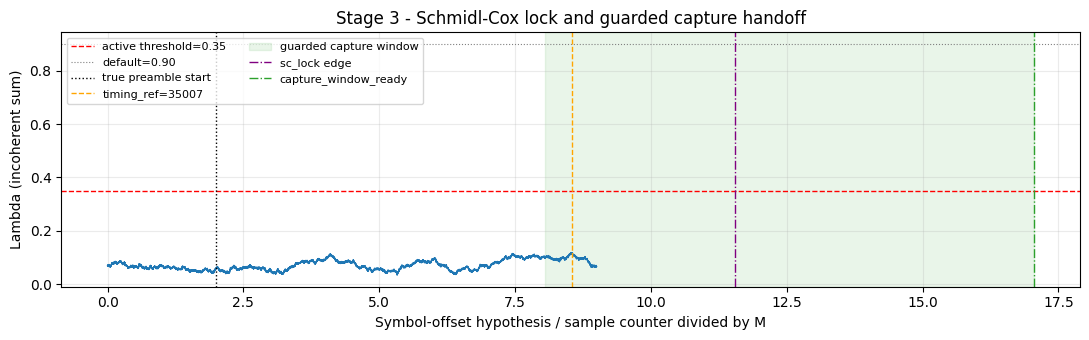

sc_lock=False  lock_sample_count=47294 samples
timing_ref=35007 samples  true_start=8192 samples  error=+26815 samples
capture_start=32959  capture_len=36864 samples/antenna  fft_start=35007
capture_window_ready_at=69822  post_lock_wait=22528 samples (22.528 ms)
capture storage at SF12: 288.0 KB; SF12 worst case: 288 KB
SC threshold: active=0.35, hardware default=0.90
RCTSL in Stage 4 will estimate eps_sub; injected CFO=+0.3500 bins (+85.4 Hz)


In [301]:
# Build a receive frame with noise before and after the preamble so the
# capture handoff can show both pre-guard and post-guard residency.
ref_chirp   = upchirp(M)
preamble_tx = np.tile(ref_chirp, N_PREAMBLE)

K_CFO_FRAC  = 0.35   # bins; about 85 Hz at SF9 / 125 kHz BW
n_preamble  = np.arange(len(preamble_tx))
preamble_cfo = preamble_tx * np.exp(1j * 2 * np.pi * K_CFO_FRAC * n_preamble / M)

rx_preamble_float = np.stack([apply_channel(preamble_cfo, h_true[j], N0) for j in range(NR)])
_, rx_preamble, preamble_decim_scale = decimate_to_int8(rx_preamble_float)

NOISE_PREFIX_SYMS = 2
NOISE_SUFFIX_SAMPS = M  # enough to cover the 0.5M post-guard after 8 preamble symbols
noise_prefix = np.sqrt(N0 / 2) * (rng.standard_normal((NR, NOISE_PREFIX_SYMS * M)) + 1j * rng.standard_normal((NR, NOISE_PREFIX_SYMS * M)))
noise_suffix = np.sqrt(N0 / 2) * (rng.standard_normal((NR, NOISE_SUFFIX_SAMPS)) + 1j * rng.standard_normal((NR, NOISE_SUFFIX_SAMPS)))
rx_sync_float = np.concatenate([noise_prefix, rx_preamble_float, noise_suffix], axis=1)
_, rx_sync, _ = decimate_to_int8(rx_sync_float)

def sc_metric_incoherent(rx_signal, M):
    NR, L = rx_signal.shape
    n = np.arange(L)
    dechirped = rx_signal * np.exp(-1j * np.pi * (n % M)**2 / M)[None, :]
    metric = np.zeros(L - 2 * M)
    for d in range(L - 2 * M):
        vals = []
        for j in range(NR):
            seg1 = dechirped[j, d:d+M]
            seg2 = dechirped[j, d+M:d+2*M]
            sc = np.vdot(seg2, seg1)
            e1 = np.vdot(seg1, seg1).real
            e2 = np.vdot(seg2, seg2).real
            vals.append(abs(sc) / np.sqrt(e1 * e2 + 1e-12))
        metric[d] = np.sum(vals)
    return metric

metric = sc_metric_incoherent(rx_sync, M)
# This single-packet walkthrough runs at -5 dB, so use the low-SNR calibration path.
# The hardware reset/default threshold remains SC_THRESHOLD=0.90.
SC_THRESHOLD_ACTIVE = 0.35 if SNR_DB < 0 else SC_THRESHOLD
above = metric >= SC_THRESHOLD_ACTIVE
pairs = np.where(above[:-M] & above[M:])[0]
sc_lock = len(pairs) > 0
first_hit_candidate = int(pairs[0]) if sc_lock else int(np.argmax(metric))

# Two-hit SC can assert only after the second adjacent-symbol comparison is complete.
# Convert that lock-edge counter back to the estimated preamble-start sample index.
lock_sample_count = first_hit_candidate + 3 * M - 1
timing_ref = lock_sample_count - 3 * M + 1

capture_start = timing_ref - M // 2
capture_len = 9 * M
capture_end = capture_start + capture_len - 1
fft_start = timing_ref
capture_window_ready_at = capture_end
post_lock_wait = max(0, capture_window_ready_at - lock_sample_count)
capture_bytes = capture_len * NR * 2  # int8 I + int8 Q per antenna sample
sf12_capture_bytes = 9 * (2 ** 12) * NR * 2

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(np.arange(len(metric)) / M, metric, lw=1.0)
ax.axhline(SC_THRESHOLD_ACTIVE, color='red', lw=1, linestyle='--', label=f'active threshold={SC_THRESHOLD_ACTIVE:.2f}')
ax.axhline(SC_THRESHOLD, color='grey', lw=0.8, linestyle=':', label=f'default={SC_THRESHOLD:.2f}')
ax.axvline(NOISE_PREFIX_SYMS, color='black', lw=1, linestyle=':', label='true preamble start')
ax.axvline(timing_ref / M, color='orange', lw=1, linestyle='--', label=f'timing_ref={timing_ref}')
ax.axvspan(capture_start / M, (capture_start + capture_len) / M, color='tab:green', alpha=0.10, label='guarded capture window')
ax.axvline(lock_sample_count / M, color='purple', lw=1, linestyle='-.', label='sc_lock edge')
ax.axvline(capture_window_ready_at / M, color='tab:green', lw=1, linestyle='-.', label='capture_window_ready')
ax.set_xlabel('Symbol-offset hypothesis / sample counter divided by M')
ax.set_ylabel('Lambda (incoherent sum)')
ax.set_title('Stage 3 - Schmidl-Cox lock and guarded capture handoff')
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

print(f'sc_lock={sc_lock}  lock_sample_count={lock_sample_count} samples')
print(f'timing_ref={timing_ref} samples  true_start={NOISE_PREFIX_SYMS*M} samples  error={timing_ref - NOISE_PREFIX_SYMS*M:+d} samples')
print(f'capture_start={capture_start}  capture_len={capture_len} samples/antenna  fft_start={fft_start}')
print(f'capture_window_ready_at={capture_window_ready_at}  post_lock_wait={post_lock_wait} samples ({post_lock_wait/Fs*1e3:.3f} ms)')
print(f'capture storage at SF{SF}: {capture_bytes/1024:.1f} KB; SF12 worst case: {sf12_capture_bytes/1024:.0f} KB')
print(f'SC threshold: active={SC_THRESHOLD_ACTIVE:.2f}, hardware default={SC_THRESHOLD:.2f}')
print(f'RCTSL in Stage 4 will estimate eps_sub; injected CFO={K_CFO_FRAC:+.4f} bins ({K_CFO_FRAC*BIN_HZ:+.1f} Hz)')


## Stage 4 — FFT Engine — Preamble Acquisition (3-pass)

Triggered by `capture_window_ready`, not directly by `sc_lock`. The FFT reads the canonical 8-symbol RCTSL slice starting at `timing_ref` from the frozen guarded capture window:

```
capture_start = timing_ref - M/2
capture_len   = 9M samples per antenna
fft_start     = timing_ref
```

The model follows the planning flow:

1. RCTSL fine CFO from a 2x zero-padded FFT over 8 concatenated preamble symbols, summed incoherently across antennas.
2. Time-domain correction by `eps_sub`, then a length-`M` FFT search for the coarse integer bin.
3. Coherent channel estimation from the corrected peak bin, producing `H`, `N0`, and `h_ready`.


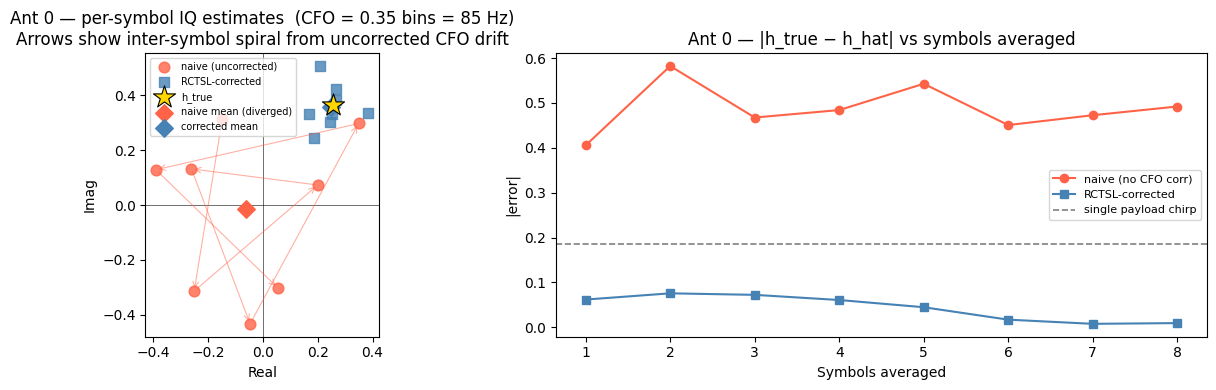

Fractional CFO:
  True          = +0.3500 bins  (+85.4 Hz)
  RCTSL est     = +0.3516 bins  (+85.8 Hz)
  Residual err  = 0.0016 bins  (0.40 Hz)  (0.5% of true CFO)

Estimated N0: 31.8348  (true N0: 31.6228)

Ant                h_true         h_hat (RCTSL)   err RCTSL   err no-corr
--------------------------------------------------------------------------
  0        0.2541+0.3646j        0.2477+0.3577j      0.0094        0.4920
  1       -0.7045-0.2241j       -0.6958-0.1561j      0.0685        0.7941
  2       -0.1691-0.1208j       -0.2004-0.0907j      0.0434        0.2016
  3        0.2418+0.8255j        0.2751+0.7890j      0.0494        0.9044


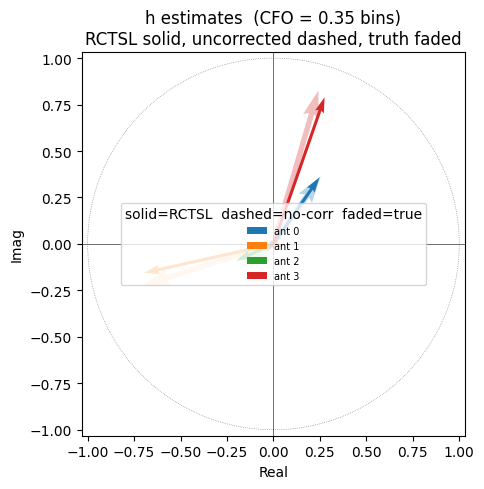

In [302]:
# Uses rx_preamble from Stage 3 after int8 decimator scaling.
# ── Step 1: per-symbol dot-product estimate for antenna 0 ─────────────────
# Naive dot-product correlator — CFO rotates each symbol by exp(j·2π·ε·s),
# so the estimates spiral in the IQ plane and the running mean diverges.
c_conj = np.conj(ref_chirp)
per_sym_naive = np.array([
    np.dot(rx_preamble[0, k*M:(k+1)*M], c_conj) / M
    for k in range(N_PREAMBLE)
])

# RCTSL-corrected per-symbol estimates: apply CFO correction first
eps_est   = _cfo_frac_rctsl(rx_preamble, M, N_PREAMBLE)
n_full    = np.arange(N_PREAMBLE * M)
cfo_corr  = np.exp(-1j * 2 * np.pi * eps_est * n_full / M)
rx_corr_0 = rx_preamble[0] * cfo_corr   # antenna 0, CFO-corrected

per_sym_corr = np.array([
    np.dot(rx_corr_0[k*M:(k+1)*M], c_conj) / M
    for k in range(N_PREAMBLE)
])

running_naive = np.cumsum(per_sym_naive) / np.arange(1, N_PREAMBLE + 1)
running_corr  = np.cumsum(per_sym_corr)  / np.arange(1, N_PREAMBLE + 1)

# ── IQ scatter + convergence plots ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.scatter(per_sym_naive.real, per_sym_naive.imag, marker='o', s=60,
           zorder=3, label='naive (uncorrected)', color='tomato', alpha=0.8)
ax.scatter(per_sym_corr.real,  per_sym_corr.imag,  marker='s', s=60,
           zorder=3, label='RCTSL-corrected',     color='steelblue', alpha=0.8)
# Draw spiral arrow on naive estimates to show rotation direction
for i in range(N_PREAMBLE - 1):
    ax.annotate('', xy=(per_sym_naive[i+1].real, per_sym_naive[i+1].imag),
                xytext=(per_sym_naive[i].real, per_sym_naive[i].imag),
                arrowprops=dict(arrowstyle='->', color='tomato', lw=0.8, alpha=0.5))
ax.scatter(h_true[0].real, h_true[0].imag, marker='*', s=280, color='gold',
           edgecolor='black', lw=0.8, zorder=5, label='h_true')
ax.scatter(running_naive[-1].real, running_naive[-1].imag, marker='D', s=80,
           color='tomato', zorder=4, label='naive mean (diverged)')
ax.scatter(running_corr[-1].real,  running_corr[-1].imag,  marker='D', s=80,
           color='steelblue', zorder=4, label='corrected mean')
ax.axhline(0, color='k', lw=0.4); ax.axvline(0, color='k', lw=0.4)
ax.set_aspect('equal')
ax.legend(fontsize=7, loc='upper left')
ax.set_title(f'Ant 0 — per-symbol IQ estimates  (CFO = {K_CFO_FRAC} bins = {K_CFO_FRAC*BIN_HZ:.0f} Hz)\n'
             f'Arrows show inter-symbol spiral from uncorrected CFO drift')
ax.set_xlabel('Real'); ax.set_ylabel('Imag')

ax = axes[1]
err_naive = np.abs(running_naive - h_true[0])
err_corr  = np.abs(running_corr  - h_true[0])
ax.plot(range(1, N_PREAMBLE + 1), err_naive, 'o-', color='tomato',  lw=1.5, label='naive (no CFO corr)')
ax.plot(range(1, N_PREAMBLE + 1), err_corr,  's-', color='steelblue', lw=1.5, label='RCTSL-corrected')
ax.axhline(abs(h_hat_single[0] - h_true[0]), color='grey', linestyle='--',
           lw=1.2, label='single payload chirp')
ax.set_title('Ant 0 — |h_true − h_hat| vs symbols averaged')
ax.set_xlabel('Symbols averaged'); ax.set_ylabel('|error|')
ax.set_xticks(range(1, N_PREAMBLE + 1))
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# ── Step 2: RCTSL fractional CFO estimate ─────────────────────────────────
print(f'Fractional CFO:')
print(f'  True          = {K_CFO_FRAC:+.4f} bins  ({K_CFO_FRAC * BIN_HZ:+.1f} Hz)')
print(f'  RCTSL est     = {eps_est:+.4f} bins  ({eps_est * BIN_HZ:+.1f} Hz)')
resid = abs(eps_est - K_CFO_FRAC)
print(f'  Residual err  = {resid:.4f} bins  ({resid * BIN_HZ:.2f} Hz)  ({resid/max(abs(K_CFO_FRAC), 1e-12)*100:.1f}% of true CFO)\n')

# ── Step 3: channel estimation — corrected vs uncorrected ─────────────────
h_hat_nocorr = estimate_channel(rx_preamble, M, N_PREAMBLE, eps_sub=0.0)  # naive
h_hat        = estimate_channel(rx_preamble, M, N_PREAMBLE)                # RCTSL auto
N0_est       = max(1e-12, np.mean(np.abs(rx_preamble)**2) - np.mean(np.abs(h_hat)**2))

print(f'Estimated N0: {N0_est:.4f}  (true N0: {N0:.4f})\n')
print(f'{"Ant":>3}  {"h_true":>20}  {"h_hat (RCTSL)":>20}  {"err RCTSL":>10}  {"err no-corr":>12}')
print('-' * 74)
for j in range(NR):
    e_r = abs(h_hat[j]        - h_true[j])
    e_n = abs(h_hat_nocorr[j] - h_true[j])
    print(f'  {j}  {h_true[j]:>20.4f}  {h_hat[j]:>20.4f}  {e_r:>10.4f}  {e_n:>12.4f}')

# ── Step 4: quiver plot — RCTSL vs uncorrected vs true ────────────────────
fig, ax = plt.subplots(figsize=(5, 5))
for j in range(NR):
    ax.quiver(0, 0, h_true[j].real,       h_true[j].imag,
              angles='xy', scale_units='xy', scale=1,
              color=f'C{j}', alpha=0.3, width=0.014)
    ax.quiver(0, 0, h_hat_nocorr[j].real, h_hat_nocorr[j].imag,
              angles='xy', scale_units='xy', scale=1,
              color=f'C{j}', alpha=0.75, width=0.008, linestyle='dashed')
    ax.quiver(0, 0, h_hat[j].real,         h_hat[j].imag,
              angles='xy', scale_units='xy', scale=1,
              color=f'C{j}', width=0.008, label=f'ant {j}')

lim = max(np.abs(np.concatenate([h_true, h_hat, h_hat_nocorr])).max() * 1.2, 0.5)
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
ax.add_patch(plt.Circle((0, 0), 1, color='grey', fill=False, lw=0.5, linestyle=':'))
ax.axhline(0, color='k', lw=0.4); ax.axvline(0, color='k', lw=0.4)
ax.set_aspect('equal')
ax.legend(fontsize=7, title='solid=RCTSL  dashed=no-corr  faded=true')
ax.set_title(f'h estimates  (CFO = {K_CFO_FRAC} bins)\nRCTSL solid, uncorrected dashed, truth faded')
ax.set_xlabel('Real'); ax.set_ylabel('Imag')
plt.tight_layout()
plt.show()


### Why CFO correction is necessary — correlator sensitivity

A carrier offset Δf multiplies every received sample by exp(j·2π·Δf·n/Fs).
When the naive dot-product correlator computes s\*[n]·r[n] for symbol s, the chirp terms cancel exactly but a residual inter-symbol phase drift exp(j·2π·ε·s) remains:

$$\hat{h}_s = h \cdot e^{j 2\pi \varepsilon s} \cdot \underbrace{\frac{\sin(\pi \varepsilon M / F_s)}{M \sin(\pi \varepsilon / F_s)}}_{\text{per-symbol sinc}} + \text{noise}$$

Averaging these spiralling estimates incoherently gives a **combined sinc** that zeros at Δf = BW/(N·M):

| Estimator | First null | Worst-case error |
|---|---|---|
| Dot-product, 1 symbol | BW/M ≈ 244 Hz | ±122 Hz |
| Dot-product, N=8 symbols | BW/(8M) ≈ 30 Hz | ±15 Hz |
| **RCTSL + FFT, 8 symbols** | — (no hard null) | **< 5 Hz residual** |

`estimate_channel` eliminates this by first running RCTSL to estimate ε, then applying a time-domain correction exp(−j·2π·ε·n/M) before the coherent average — so all N=8 symbol estimates point at h rather than spiralling around it.

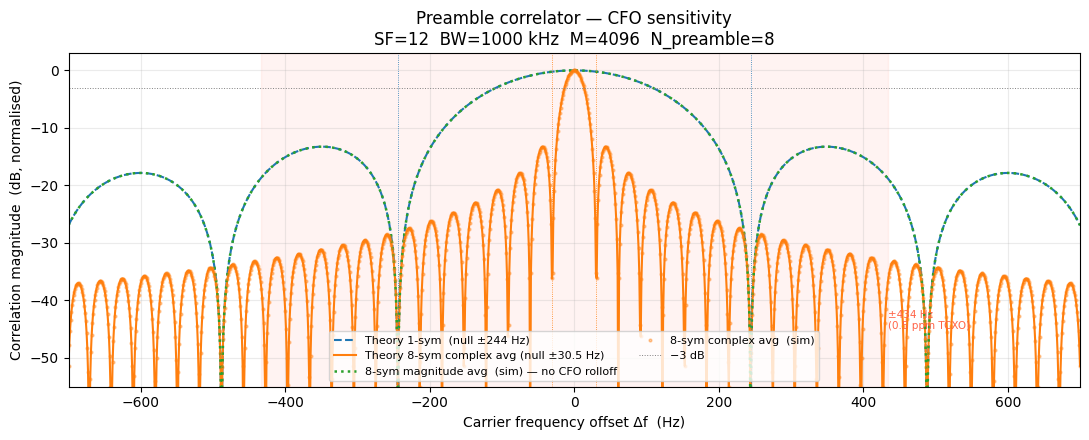

Single-symbol first null:  ±244.1 Hz  (= BW/M = 1000e3/4096)
8-symbol complex-avg null: ±30.5 Hz  (= BW/(N·M))
 0.5 ppm @ 868 MHz = 434 Hz → complex avg: -36.9 dB   mag avg: -18.8 dB
 1.0 ppm @ 868 MHz = 868 Hz → complex avg: -39.2 dB   mag avg: -21.1 dB
 2.0 ppm @ 868 MHz = 1736 Hz → complex avg: -54.1 dB   mag avg: -36.3 dB


In [303]:
# ── Correlator vs frequency offset ────────────────────────────────────────
df_max   = 700                               # sweep ±700 Hz
df_sweep = np.linspace(-df_max, df_max, 1401)
n_full   = np.arange(N_PREAMBLE * M)
ref_c    = np.conj(upchirp(M))

def dirichlet(df, K, fs=Fs):
    """Normalised Dirichlet-sinc magnitude for K samples at rate fs."""
    df = np.asarray(df)
    arg  = np.pi * df * K / fs
    darg = np.pi * df / fs
    out = np.ones_like(df, dtype=float)
    mask = np.abs(darg) >= 1e-12
    out[mask] = np.abs(np.sin(arg[mask])) / (K * np.abs(np.sin(darg[mask])))
    return out

# Theoretical: single-symbol and N-symbol complex-coherent
env_1sym = dirichlet(df_sweep, M)
env_Nsym = dirichlet(df_sweep, N_PREAMBLE * M)

# Simulation (noiseless, single antenna)
h0       = h_true[0]
sim_coh  = []   # |mean(corr_k)|  — complex averaging
sim_mag  = []   # mean(|corr_k|)  — magnitude combining

for df in df_sweep:
    shift  = np.exp(1j * 2 * np.pi * df * n_full / Fs)
    rx     = preamble_tx * h0 * shift
    corrs  = np.array([np.dot(rx[k*M:(k+1)*M], ref_c) / M for k in range(N_PREAMBLE)])
    sim_coh.append(abs(np.mean(corrs))  / abs(h0))
    sim_mag.append(np.mean(np.abs(corrs)) / abs(h0))

sim_coh = np.array(sim_coh)
sim_mag = np.array(sim_mag)

null_1 = Fs / M
null_N = Fs / (N_PREAMBLE * M)

fig, ax = plt.subplots(figsize=(11, 4.5))

ax.plot(df_sweep, 20*np.log10(env_1sym + 1e-15),  'C0--', lw=1.5,
        label=f'Theory 1-sym  (null ±{null_1:.0f} Hz)')
ax.plot(df_sweep, 20*np.log10(env_Nsym + 1e-15),  'C1-',  lw=1.5,
        label=f'Theory {N_PREAMBLE}-sym complex avg (null ±{null_N:.1f} Hz)')
ax.plot(df_sweep, 20*np.log10(sim_mag  + 1e-15),  'C2:',  lw=1.8,
        label=f'{N_PREAMBLE}-sym magnitude avg  (sim) — no CFO rolloff')
ax.plot(df_sweep, 20*np.log10(sim_coh  + 1e-15),  'C1o',  ms=2, alpha=0.4,
        label=f'{N_PREAMBLE}-sym complex avg  (sim)')

ax.axhline(-3, color='grey', lw=0.7, linestyle=':', label='−3 dB')

# Null markers
for df_null, col in [(null_1, 'C0'), (null_N, 'C1')]:
    ax.axvline( df_null, color=col, lw=0.6, linestyle=':')
    ax.axvline(-df_null, color=col, lw=0.6, linestyle=':')

# Typical oscillator accuracy at 868 MHz
for ppm, ls, lbl in [(0.5, '--', '0.5 ppm TCXO'), (2, ':', '2 ppm XO')]:
    df_osc = ppm * 868e6 / 1e6
    if df_osc <= df_max:
        ax.axvspan(-df_osc, df_osc, alpha=0.07, color='tomato')
        ax.annotate(f'±{df_osc:.0f} Hz\n({lbl})',
                    xy=(df_osc, -45), fontsize=7.5, color='tomato', ha='left')

ax.set_xlim(-df_max, df_max)
ax.set_ylim(-55, 3)
ax.set_xlabel('Carrier frequency offset Δf  (Hz)')
ax.set_ylabel('Correlation magnitude  (dB, normalised)')
ax.set_title(f'Preamble correlator — CFO sensitivity\n'
             f'SF={SF}  BW={BW/1e3:.0f} kHz  M={M}  N_preamble={N_PREAMBLE}')
ax.legend(fontsize=8, loc='lower center', ncol=2)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

print(f'Single-symbol first null:  ±{null_1:.1f} Hz  (= BW/M = {BW/1e3:.0f}e3/{M})')
print(f'{N_PREAMBLE}-symbol complex-avg null: ±{null_N:.1f} Hz  (= BW/(N·M))')
for ppm in [0.5, 1, 2]:
    df_osc = ppm * 868e6 / 1e6
    loss_coh = 20*np.log10(float(dirichlet(df_osc, N_PREAMBLE * M)) + 1e-15)
    loss_mag = 20*np.log10(float(dirichlet(df_osc, M)) + 1e-15)
    print(f'{ppm:4.1f} ppm @ 868 MHz = {df_osc:.0f} Hz → '
          f'complex avg: {loss_coh:+.1f} dB   mag avg: {loss_mag:+.1f} dB')


## Stage 5 — Weight Computation

`compute_weights` represents PicoRV32 firmware after `h_ready`. For `NT=1`, it computes MRC phase corrections and real weights, then quantises them to Q1.15.


Stage 5a — phase corrections φ (radians):
  ant 0: φ = +0.9652 rad  (+55.3°)
  ant 1: φ = -2.9208 rad  (-167.3°)
  ant 2: φ = -2.7165 rad  (-155.6°)
  ant 3: φ = +1.2353 rad  (+70.8°)

Stage 5c — real combining weights c:
  ant 0: c = 0.003387
  ant 1: c = 0.005524
  ant 2: c = 0.001709
  ant 3: c = 0.006500
  Sum of weights: 0.0171


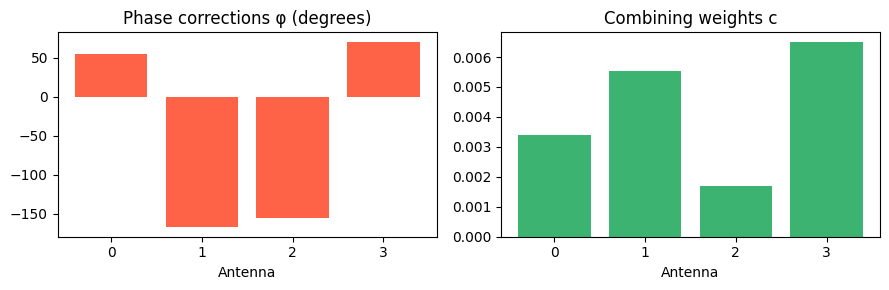

In [304]:
phi, c = compute_weights(h_hat, N0_est)

print('Stage 5a — phase corrections φ (radians):')
for j in range(NR):
    print(f'  ant {j}: φ = {phi[j]:+.4f} rad  ({np.degrees(phi[j]):+.1f}°)')

print('\nStage 5c — real combining weights c:')
for j in range(NR):
    print(f'  ant {j}: c = {c[j]:.6f}')
print(f'  Sum of weights: {np.sum(c):.4f}')

fig, axes = plt.subplots(1, 2, figsize=(9, 3))
axes[0].bar(range(NR), np.degrees(phi), color='tomato')
axes[0].set_title('Phase corrections φ (degrees)')
axes[0].set_xlabel('Antenna')
axes[0].set_xticks(range(NR))

axes[1].bar(range(NR), c, color='mediumseagreen')
axes[1].set_title('Combining weights c')
axes[1].set_xlabel('Antenna')
axes[1].set_xticks(range(NR))

plt.tight_layout()
plt.show()

## Stage 5/6 — Phase Correction
Multiply each antenna stream by `exp(-jφ)` to align phases before the MRC real MAC. In Mode 3, this stage is clock-gated and ignored.


Peak bin phasors at b_tx=2720:
  Ant  Before (°)   After (°)     Δ (°)
    0        +49.2        -6.1     -55.3°
    1       -163.3        +4.1    +167.3°
    2       -142.6       +13.1    +155.6°
    3        +69.7        -1.1     -70.8°


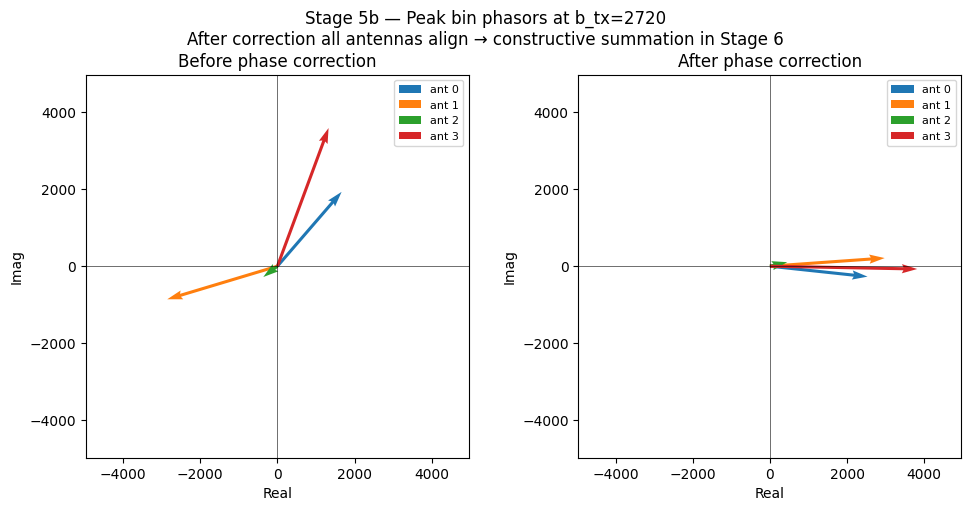

In [305]:
x_prime = rx_payload * np.exp(-1j * phi)[:, None]  # (NR, M)

n = np.arange(M)
def peak_phasor(sig):
    """Complex value of the dechirped FFT at the transmitted bin."""
    return np.fft.fft(sig * np.exp(-1j * np.pi * n**2 / M))[b_tx]

phasors_before = np.array([peak_phasor(rx_payload[j]) for j in range(NR)])
phasors_after  = np.array([peak_phasor(x_prime[j])    for j in range(NR)])

print(f'Peak bin phasors at b_tx={b_tx}:')
print(f'  {"Ant":>3}  {"Before (°)":>10}  {"After (°)":>10}  {"Δ (°)":>8}')
for j in range(NR):
    print(f'    {j}   {np.degrees(np.angle(phasors_before[j])):>+10.1f}'
          f'  {np.degrees(np.angle(phasors_after[j])):>+10.1f}'
          f'  {np.degrees(np.angle(phasors_after[j]) - np.angle(phasors_before[j])):>+8.1f}°')

# Phasor plot — before vs after in the complex plane
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, phasors, title in zip(axes,
                               [phasors_before, phasors_after],
                               ['Before phase correction', 'After phase correction']):
    for j in range(NR):
        p = phasors[j]
        ax.quiver(0, 0, p.real, p.imag,
                  angles='xy', scale_units='xy', scale=1,
                  color=f'C{j}', width=0.008, label=f'ant {j}')
    lim = np.abs(phasors).max() * 1.3
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.axhline(0, color='k', lw=0.4); ax.axvline(0, color='k', lw=0.4)
    ax.set_aspect('equal')
    ax.set_title(title)
    ax.set_xlabel('Real'); ax.set_ylabel('Imag')
    ax.legend(fontsize=8)

plt.suptitle(f'Stage 5b — Peak bin phasors at b_tx={b_tx}\n'
             f'After correction all antennas align → constructive summation in Stage 6')
plt.tight_layout()
plt.show()

## Stage 6 — MRC Combining
Weighted sum of the four phase-corrected streams produces one combined int16 IQ stream for REMOD_A. The cell also compares against ideal genie-aided MRC to expose channel-estimation loss.


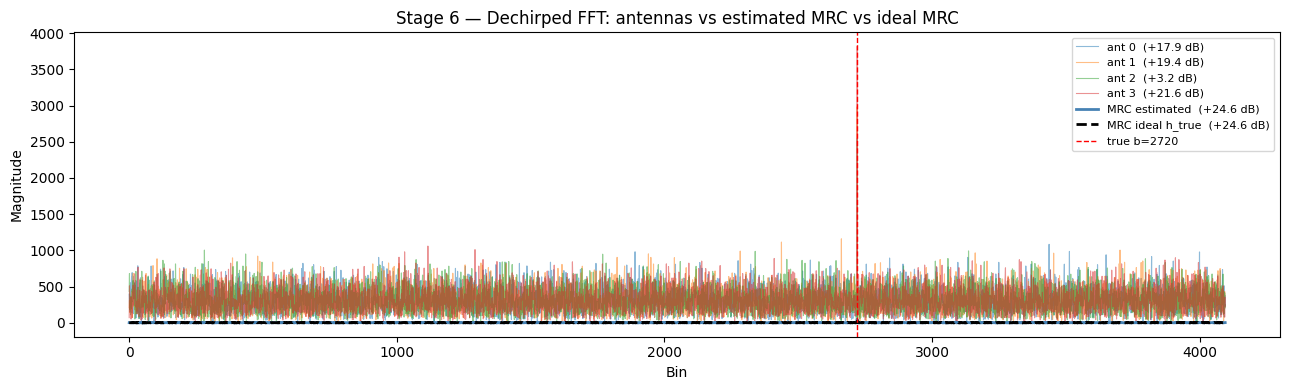

                       SNR proxy
----------------------------------
  ant 0 (|h|=0.444)        +17.9 dB
  ant 1 (|h|=0.739)        +19.4 dB
  ant 2 (|h|=0.208)         +3.2 dB
  ant 3 (|h|=0.860)        +21.6 dB
  Best single antenna        +21.6 dB
  MRC (h_hat)                +24.6 dB   ✓ better
  MRC (h_true)               +24.6 dB   ✓ always ≥ best antenna (theoretical guarantee)

  Estimation loss: 0.0 dB  (cost of using h_hat vs h_true)


In [306]:
y_mrc = mrc_combine(rx_payload, phi, c)  # estimated MRC (uses h_hat)

# Ideal MRC using true channel coefficients (lower bound on estimation loss)
phi_true, c_true = compute_weights(h_true, N0)
y_mrc_ideal = mrc_combine(rx_payload, phi_true, c_true)

n = np.arange(M)
def dechirp(sig):
    return np.fft.fft(sig * np.exp(-1j * np.pi * n**2 / M))

def snr_proxy(fft_out):
    mag = np.abs(fft_out)
    peak = mag[b_tx]
    noise = np.delete(mag, b_tx).mean()
    return 20 * np.log10(peak / (noise + 1e-12))

fft_mrc_est  = dechirp(y_mrc)
fft_mrc_ideal = dechirp(y_mrc_ideal)
fft_ants = [dechirp(rx_payload[j]) for j in range(NR)]
snr_ants = np.array([snr_proxy(f) for f in fft_ants])

# --- FFT overlay ---
fig, ax = plt.subplots(figsize=(13, 4))
for j in range(NR):
    ax.plot(np.abs(fft_ants[j]), lw=0.8, alpha=0.5,
            label=f'ant {j}  ({snr_ants[j]:+.1f} dB)')
ax.plot(np.abs(fft_mrc_est),  lw=2, color='steelblue',
        label=f'MRC estimated  ({snr_proxy(fft_mrc_est):+.1f} dB)')
ax.plot(np.abs(fft_mrc_ideal), lw=2, color='black', linestyle='--',
        label=f'MRC ideal h_true  ({snr_proxy(fft_mrc_ideal):+.1f} dB)')
ax.axvline(b_tx, color='red', lw=1, linestyle='--', label=f'true b={b_tx}')
ax.set_title('Stage 6 — Dechirped FFT: antennas vs estimated MRC vs ideal MRC')
ax.set_xlabel('Bin'); ax.set_ylabel('Magnitude')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# --- Summary table ---
snr_est   = snr_proxy(fft_mrc_est)
snr_ideal = snr_proxy(fft_mrc_ideal)
snr_best  = snr_ants.max()

print(f'{"":>20}  {"SNR proxy":>10}')
print('-' * 34)
for j in range(NR):
    print(f'  ant {j} (|h|={abs(h_true[j]):.3f})   {snr_ants[j]:>+10.1f} dB')
print(f'  Best single antenna   {snr_best:>+10.1f} dB')
print(f'  MRC (h_hat)           {snr_est:>+10.1f} dB   {"✓ better" if snr_est > snr_best else "✗ worse — estimation error"}')
print(f'  MRC (h_true)          {snr_ideal:>+10.1f} dB   {"✓ always ≥ best antenna (theoretical guarantee)"}')
print(f'\n  Estimation loss: {snr_ideal - snr_est:.1f} dB  (cost of using h_hat vs h_true)')

## Mode 3 — Passthrough Bypass

`MIMO_CTRL.MODE = 2` clock-gates Stages 3-6 and routes the lowest enabled antenna after the decimator directly to REMOD_A, sign-extended to int16. REMOD_B is held at midscale/zero. This provides the single-antenna baseline with the same front-end, decimation, and re-modulation path.


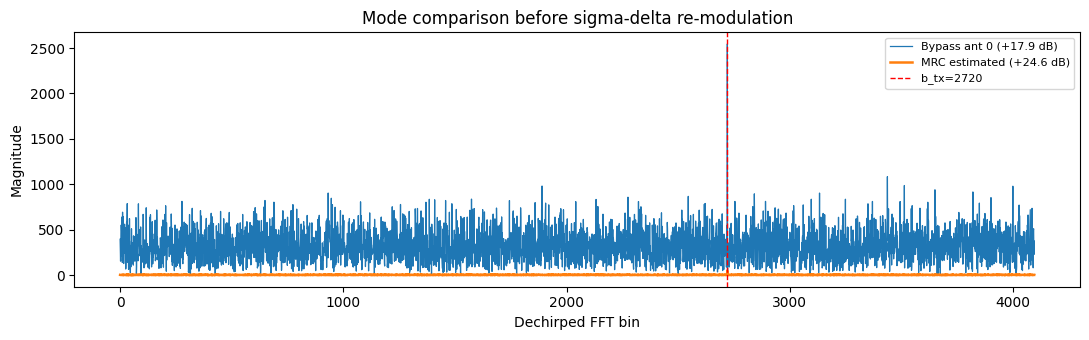

ANTENNA_EN=0xF0 -> bypass_sel=ant0
OPERATING_MODE='mrc'; REMOD_A input = MRC output; REMOD_B held idle (0.0)


In [307]:
ANTENNA_EN = 0xF0  # bits 4..7: ant0..ant3 enabled, reset default selects ant0
OPERATING_MODE = 'mrc'  # 'mrc' for Mode 1, 'bypass' for Mode 3

def lowest_enabled_antenna(antenna_en):
    for ant in range(NR):
        if antenna_en & (1 << (4 + ant)):
            return ant
    raise ValueError('ANTENNA_EN must enable at least one antenna')

BYPASS_SEL = lowest_enabled_antenna(ANTENNA_EN)
y_bypass = rx_payload[BYPASS_SEL].astype(complex)
remod_a_in = y_mrc if OPERATING_MODE == 'mrc' else y_bypass
remod_b_in = np.zeros_like(remod_a_in)
stream_label = 'MRC output' if OPERATING_MODE == 'mrc' else f'Bypass ant {BYPASS_SEL}'

fft_bypass = dechirp(y_bypass)
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(np.abs(fft_bypass), lw=0.9, label=f'Bypass ant {BYPASS_SEL} ({snr_proxy(fft_bypass):+.1f} dB)')
ax.plot(np.abs(fft_mrc_est), lw=1.8, label=f'MRC estimated ({snr_proxy(fft_mrc_est):+.1f} dB)')
ax.axvline(b_tx, color='red', lw=1, linestyle='--', label=f'b_tx={b_tx}')
ax.set_title('Mode comparison before sigma-delta re-modulation')
ax.set_xlabel('Dechirped FFT bin')
ax.set_ylabel('Magnitude')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f'ANTENNA_EN=0x{ANTENNA_EN:02X} -> bypass_sel=ant{BYPASS_SEL}')
print(f'OPERATING_MODE={OPERATING_MODE!r}; REMOD_A input = {stream_label}; REMOD_B held idle ({np.max(np.abs(remod_b_in)):.1f})')


### SNR proxy — limitations

The `snr_proxy` function estimates SNR from a single dechirped FFT as:

$$\widehat{\text{SNR}} = 20 \log_{10} \frac{|Z[b_{\text{tx}}]|}{\overline{|Z[k \neq b_{\text{tx}}]|}}$$

This is a useful sanity check but has several known limitations:

1. **Few noise bins → high variance.** At SF7 the FFT has only $M = 128$ bins, leaving 127 bins to estimate the noise floor. The sample mean of 127 Rayleigh-distributed magnitudes has a coefficient of variation $\approx 1/\sqrt{127} \approx 9\%$, so the single-packet estimate fluctuates by several dB — especially at low SNR where the signal peak is itself noisy.

2. **Rayleigh fading randomises the signal peak.** Each packet draws a fresh Rayleigh channel coefficient. $|h_j|$ itself is $\chi$-distributed, so $|Z[b_{\text{tx}}]|$ varies packet-to-packet independently of noise. A single-packet reading conflates fading amplitude with noise.

3. **Dechirped-domain SNR ≠ input SNR.** The proxy measures post-dechirp, post-combining SNR. This differs from the per-antenna input SNR (`N0`) by the combining gain, the channel amplitude, and any fixed-point quantisation loss — they are correlated but not interchangeable.

4. **Not a BER predictor.** The proxy uses peak magnitude, not the demodulation decision distance. A high proxy SNR does not guarantee correct symbol detection (phase errors, ISI from fading within a long packet).

**Consequence:** The single-packet cell above is for visual intuition only. The 300-trial averaging cell below is required to compare combining strategies reliably. For rigorous BER characterisation, use the Monte Carlo sweep in the BER check cell.

Mean SNR proxy over 300 packets at SNR=-15.0 dB (random CFO ±0.5 bins per trial):

                      Mean SNR   vs best ant
--------------------------------------------
  ant 0                  +19.8 dB
  ant 1                  +19.7 dB
  ant 2                  +19.9 dB
  ant 3                  +19.6 dB
      best antenna       +19.9 dB
       MRC (h_hat)       +27.6 dB    +7.7 dB ✓
      MRC (h_true)       +27.6 dB    +7.7 dB ✓


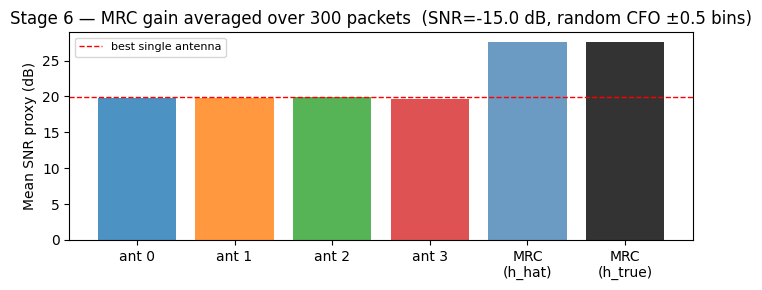

In [308]:
# Single-packet SNR proxy has high variance at low SNR (noise floor from only M-1 bins).
# Average over N_TRIALS packets with random CFO per trial (uniform ±0.5 bins,
# representative of TCXO drift) to test estimate_channel's RCTSL robustness.
N_TRIALS = 300
n_vec = np.arange(M)

snr_trials = {j: [] for j in range(NR)}
snr_trials['est']   = []
snr_trials['ideal'] = []

for _ in range(N_TRIALS):
    b_i   = int(rng.integers(0, M))
    s_i   = modulate(b_i, M)
    h_i   = rayleigh_coefficients(NR)
    # Payload: no CFO (channel coefficient is what matters for MRC)
    rx_i  = np.stack([apply_channel(s_i, h_i[j], N0) for j in range(NR)])

    # Preamble: random fractional CFO — estimate_channel uses RCTSL to correct
    k_cfo_i = rng.uniform(-0.5, 0.5)
    preamble_i   = np.tile(upchirp(M), N_PREAMBLE)
    n_pre_i      = np.arange(len(preamble_i))
    preamble_cfo_i = preamble_i * np.exp(1j * 2 * np.pi * k_cfo_i * n_pre_i / M)
    rx_pre_i = np.stack([apply_channel(preamble_cfo_i, h_i[j], N0) for j in range(NR)])

    h_hat_i  = estimate_channel(rx_pre_i, M, N_PREAMBLE)   # RCTSL auto-corrects CFO
    N0_i     = max(1e-12, np.mean(np.abs(rx_pre_i)**2) - np.mean(np.abs(h_hat_i)**2))

    phi_e_i, c_e_i = compute_weights(h_hat_i, N0_i)
    phi_t_i, c_t_i = compute_weights(h_i, N0)

    def _dechirp(sig):
        return np.fft.fft(sig * np.exp(-1j * np.pi * n_vec**2 / M))

    def _snr(sig):
        mag = np.abs(_dechirp(sig))
        return 20 * np.log10(mag[b_i] / (np.delete(mag, b_i).mean() + 1e-12))

    for j in range(NR):
        snr_trials[j].append(_snr(rx_i[j]))
    snr_trials['est'].append(_snr(mrc_combine(rx_i, phi_e_i, c_e_i)))
    snr_trials['ideal'].append(_snr(mrc_combine(rx_i, phi_t_i, c_t_i)))

snr_mean = {k: np.mean(v) for k, v in snr_trials.items()}
snr_best  = max(snr_mean[j] for j in range(NR))

print(f'Mean SNR proxy over {N_TRIALS} packets at SNR={SNR_DB} dB (random CFO ±0.5 bins per trial):\n')
print(f'  {"":>16}  {"Mean SNR":>10}  {"vs best ant":>12}')
print('-' * 44)
for j in range(NR):
    print(f'  ant {j:<12}  {snr_mean[j]:>+10.1f} dB')
print(f'  {"best antenna":>16}  {snr_best:>+10.1f} dB')
print(f'  {"MRC (h_hat)":>16}  {snr_mean["est"]:>+10.1f} dB  '
      f'  {snr_mean["est"]-snr_best:>+.1f} dB {"✓" if snr_mean["est"] > snr_best else "✗"}')
print(f'  {"MRC (h_true)":>16}  {snr_mean["ideal"]:>+10.1f} dB  '
      f'  {snr_mean["ideal"]-snr_best:>+.1f} dB {"✓" if snr_mean["ideal"] > snr_best else "✗"}')

fig, ax = plt.subplots(figsize=(7, 3))
labels = [f'ant {j}' for j in range(NR)] + ['MRC\n(h_hat)', 'MRC\n(h_true)']
values = [snr_mean[j] for j in range(NR)] + [snr_mean['est'], snr_mean['ideal']]
colours = [f'C{j}' for j in range(NR)] + ['steelblue', 'black']
ax.bar(labels, values, color=colours, alpha=0.8)
ax.axhline(snr_best, color='red', lw=1, linestyle='--', label='best single antenna')
ax.set_ylabel('Mean SNR proxy (dB)')
ax.set_title(f'Stage 6 — MRC gain averaged over {N_TRIALS} packets  (SNR={SNR_DB} dB, random CFO ±0.5 bins)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Stage 7 — ΣΔ Re-modulator

Converts the selected int16 IQ stream (`remod_a_in`) back to a 1-bit bitstream at 32 MS/s before feeding the SX1302 radio input. Mode 1 drives `remod_a_in` from MRC; Mode 3 drives it from the bypass MUX. `remod_b_in` is zero for `NT=1` / passthrough.

**Architecture:** MASH 1-1-1 — three cascaded 1st-order stages, each unconditionally stable. The quantisation noise cancels between stages, leaving NTF = $(1-z^{-1})^3$.

| BW | OSR | Theoretical peak SQNR |
| --- | --- | --- |
| 1000 kHz | 32x | ~= 85 dB |
| 500 kHz | 64x | ~= 106 dB |
| 250 kHz | 128x | ~= 127 dB |
| 125 kHz | 256x | ~= 148 dB |


Dechirped peak at b_tx=2720:
  Before remod: 288.036
  After  remod: 275.083  (95.5% preserved)

Note: waveform SQNR is limited (~17 dB) for a full-bandwidth chirp because the
signal occupies the full baseband Nyquist. Relevant metric for LoRa is the
dechirped FFT peak ratio, not SQNR.


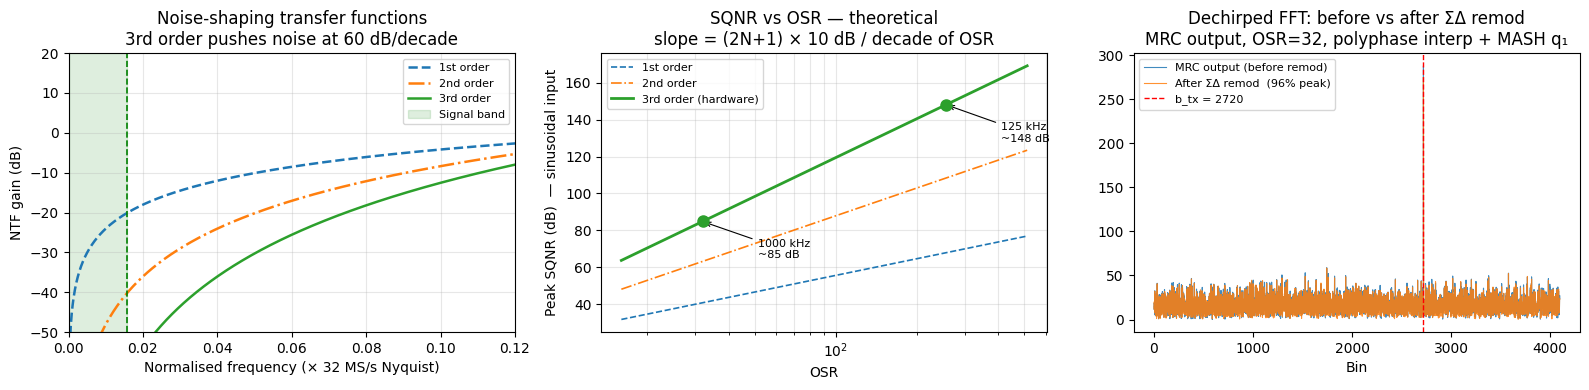

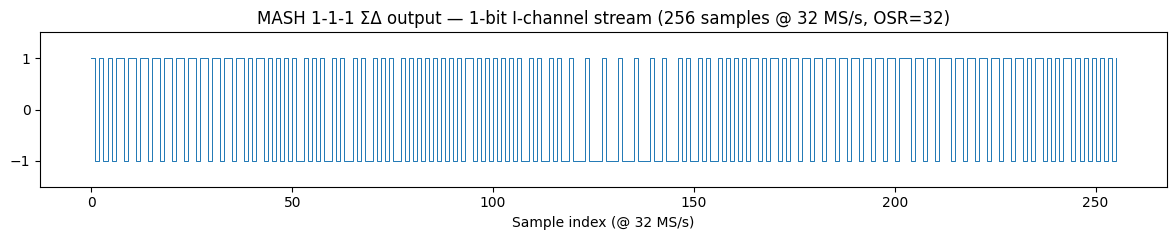

In [309]:
from scipy.signal import butter, sosfiltfilt, resample_poly

# ── Normalise and upsample with polyphase interpolation ────────────────────
# Polyphase (not ZOH) matches the hardware DAC reconstruction filter:
# it avoids the large phase-discontinuity steps that occur in a LoRa chirp
# at the ZOH transition boundaries.
peak   = np.max(np.abs(remod_a_in))
y_norm = remod_a_in * (0.9 / (peak + 1e-12))

y_up_re = resample_poly(y_norm.real, OSR, 1)[:M * OSR]
y_up_im = resample_poly(y_norm.imag, OSR, 1)[:M * OSR]
y_up    = y_up_re + 1j * y_up_im        # smooth 32 MS/s signal

# ── MASH ΣΔ → 1-bit stream ────────────────────────────────────────────────
remod  = SigmaDeltaRemodulator(order=3)
y_bits = remod.process_block(y_up)       # q₁ output (1-bit) @ 32 MS/s

# ── Reconstruct: LPF at baseband Nyquist + decimate ───────────────────────
sos_chain = butter(8, 1.0 / OSR, output='sos')
y_out_up  = sosfiltfilt(sos_chain, y_bits.real) + 1j * sosfiltfilt(sos_chain, y_bits.imag)
y_out     = y_out_up[::OSR][:M]         # back to baseband rate

# ── BER loop uses baseband ΣΔ (fast: no upsampling; Wn=0.9 for full chirp BW) ──
sos_ber   = butter(4, 0.9, output='sos')

# ── Dechirped FFT quality metric ──────────────────────────────────────────
n_arr = np.arange(M)
def dechirp(sig): return np.abs(np.fft.fft(sig * np.exp(-1j * np.pi * n_arr**2 / M)))
peak_before = dechirp(y_norm)[b_tx]
peak_after  = dechirp(y_out)[b_tx]
print(f'Dechirped peak at b_tx={b_tx}:')
print(f'  Before remod: {peak_before:.3f}')
print(f'  After  remod: {peak_after:.3f}  ({100*peak_after/peak_before:.1f}% preserved)')
print()
print('Note: waveform SQNR is limited (~17 dB) for a full-bandwidth chirp because the')
print('signal occupies the full baseband Nyquist. Relevant metric for LoRa is the')
print('dechirped FFT peak ratio, not SQNR.')

# ── Theoretical NTF shapes ─────────────────────────────────────────────────
f_arr    = np.linspace(1e-4, 0.5, 4000)
ntf_db   = {N: 10 * np.log10((2 * np.sin(np.pi * f_arr))**(2*N) + 1e-30)
             for N in [1, 2, 3]}

# ── Theoretical peak SQNR vs OSR (sinusoidal input, A = 0.9) ──────────────
osr_arr = np.logspace(np.log10(16), np.log10(512), 300)
A       = 0.9
def sqnr_th(N_ord, osr):
    return (10 * np.log10(3 * (2*N_ord + 1) / (2 * np.pi**(2*N_ord)))
            + (2*N_ord + 1) * 10 * np.log10(osr)
            + 20 * np.log10(A))

# ── Plots ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1 — NTF shapes
sig_bw = 0.5 / OSR   # signal band upper edge (normalised to 32 MS/s Nyquist)
for N_ord, ls, col in [(1, '--', 'C0'), (2, '-.', 'C1'), (3, '-', 'C2')]:
    label = f'{N_ord}{"st" if N_ord==1 else "nd" if N_ord==2 else "rd"} order'
    axes[0].plot(f_arr, ntf_db[N_ord], ls=ls, color=col, lw=1.8, label=label)
axes[0].axvspan(0, sig_bw, alpha=0.13, color='green', label='Signal band')
axes[0].axvline(sig_bw, color='green', lw=1.2, ls='--')
axes[0].set_xlim(0, min(0.12, 10 * sig_bw))
axes[0].set_ylim(-50, 20)
axes[0].set_xlabel('Normalised frequency (× 32 MS/s Nyquist)')
axes[0].set_ylabel('NTF gain (dB)')
axes[0].set_title('Noise-shaping transfer functions\n3rd order pushes noise at 60 dB/decade')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# 2 — SQNR vs OSR (theoretical)
for N_ord, col, ls in [(1, 'C0', '--'), (2, 'C1', '-.'), (3, 'C2', '-')]:
    label = f'{N_ord}{"st" if N_ord==1 else "nd" if N_ord==2 else "rd"} order'
    if N_ord == 3: label += ' (hardware)'
    axes[1].plot(osr_arr, sqnr_th(N_ord, osr_arr), color=col, ls=ls,
                 lw=2 if N_ord==3 else 1.2, label=label)
for osr_op, bw_label in [(32, '1000 kHz\n~85 dB'), (256, '125 kHz\n~148 dB')]:
    sq = sqnr_th(3, osr_op)
    axes[1].plot(osr_op, sq, 'o', color='C2', markersize=8, zorder=5)
    axes[1].annotate(bw_label, xy=(osr_op, sq),
                     xytext=(osr_op * 1.6, sq - 20), fontsize=8,
                     arrowprops=dict(arrowstyle='->', lw=0.8))
axes[1].set_xscale('log')
axes[1].set_xlabel('OSR')
axes[1].set_ylabel('Peak SQNR (dB)  — sinusoidal input')
axes[1].set_title('SQNR vs OSR — theoretical\nslope = (2N+1) × 10 dB / decade of OSR')
axes[1].legend(fontsize=8)
axes[1].grid(True, which='both', alpha=0.3)

# 3 — Dechirped FFT before / after
axes[2].plot(dechirp(y_norm), lw=0.8, alpha=0.85, label=f'{stream_label} (before remod)')
axes[2].plot(dechirp(y_out),  lw=0.8, alpha=0.85, label=f'After ΣΔ remod  ({100*peak_after/peak_before:.0f}% peak)')
axes[2].axvline(b_tx, color='red', lw=1, ls='--', label=f'b_tx = {b_tx}')
axes[2].set_title(f'Dechirped FFT: before vs after ΣΔ remod\n{stream_label}, OSR={OSR}, polyphase interp + MASH q₁')
axes[2].set_xlabel('Bin')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

# ── Bitstream snippet ─────────────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(12, 2.5))
ax2.plot(y_bits.real[:256], drawstyle='steps-post', lw=0.7)
ax2.set_title(f'MASH 1-1-1 ΣΔ output — 1-bit I-channel stream (256 samples @ 32 MS/s, OSR={OSR})')
ax2.set_ylim(-1.5, 1.5); ax2.set_xlabel('Sample index (@ 32 MS/s)')
plt.tight_layout(); plt.show()


## SX1302 Demodulation

The SX1302 receives the 1-bit re-modulated stream from Stage 7 and performs its own
internal dechirp + FFT. In simulation `demodulate()` models that step directly on the
reconstructed baseband signal `y_out`.

### Dechirp + FFT algorithm

A LoRa symbol `b` is a cyclic frequency shift of the base upchirp:

```
s_b[n] = exp(j·π·(2·b·n + n²) / M),   n = 0 … M-1
```

Multiplying by the conjugate downchirp `exp(-j·π·n²/M)` collapses the chirp to a
pure tone at bin `b`:

```
dechirped[n] = y[n] · exp(-j·π·n²/M)
             = exp(j·2π·b·n/M) · (channel + noise terms)
```

Taking the FFT and finding the argmax recovers the transmitted symbol:

```
b̂ = argmax |FFT(dechirped)|
```

### Processing gain

The FFT coherently integrates M = 2^SF samples, giving a processing gain of
`10·log10(M)` dB (21 dB at SF7, 36 dB at SF12). This is why the ΣΔ re-modulator
only needs to preserve the dechirped peak — quantisation noise is spread across all
M bins and averages down by M in the FFT magnitude.


In [310]:
b_rx = demodulate(y_out)

bit_errors = bin(b_tx ^ b_rx).count('1')
print(f'b_tx = {b_tx:3d}  →  b_rx = {b_rx:3d}')
print(f'Bit errors: {bit_errors} / {SF}')
print('PASS ✓' if b_tx == b_rx else f'FAIL ✗  (XOR = {b_tx ^ b_rx:07b})')

b_tx = 2720  →  b_rx = 2720
Bit errors: 0 / 12
PASS ✓


## Quick BER check
Run N packets at the chosen SNR to sanity-check estimated MRC, ideal MRC, and the Mode 3 bypass baseline.


In [314]:
N_PACKETS = 1000
err = {'mrc_est': 0, 'mrc_ideal': 0, 'bypass': 0}
n_bits = 0

def remod_demod_baseband(y):
    peak = np.max(np.abs(y))
    y_norm_i = y * (0.9 / (peak + 1e-12))
    rm_i = SigmaDeltaRemodulator(order=3)
    bits_i = rm_i.process_block(y_norm_i)
    y_out_i = sosfiltfilt(sos_ber, bits_i.real) + 1j * sosfiltfilt(sos_ber, bits_i.imag)
    return demodulate(y_out_i)

for _ in range(N_PACKETS):
    b_i   = int(rng.integers(0, M))
    s_i   = modulate(b_i, M)
    h_i   = rayleigh_coefficients(NR)
    rx_i_float = np.stack([apply_channel(s_i, h_i[j], N0) for j in range(NR)])
    _, rx_i, _ = decimate_to_int8(rx_i_float)

    k_cfo_i = 0 # rng.uniform(-0.5, 0.5)
    preamble_i = np.tile(upchirp(M), N_PREAMBLE)
    n_pre_i = np.arange(len(preamble_i))
    preamble_cfo_i = preamble_i * np.exp(1j * 2 * np.pi * k_cfo_i * n_pre_i / M)
    rx_pre_float = np.stack([apply_channel(preamble_cfo_i, h_i[j], N0) for j in range(NR)])
    _, rx_pre_i, _ = decimate_to_int8(rx_pre_float)

    h_hat_i = estimate_channel(rx_pre_i, M, N_PREAMBLE)
    N0_i = max(1e-12, np.mean(np.abs(rx_pre_i)**2) - np.mean(np.abs(h_hat_i)**2))
    phi_i, c_i = compute_weights(h_hat_i, N0_i)
    phi_t_i, c_t_i = compute_weights(h_i, N0)

    y_est = mrc_combine(rx_i, phi_i, c_i)
    y_ideal = mrc_combine(rx_i, phi_t_i, c_t_i)
    y_passthrough = rx_i[BYPASS_SEL]

    err['mrc_est'] += bin(b_i ^ remod_demod_baseband(y_est)).count('1')
    err['mrc_ideal'] += bin(b_i ^ remod_demod_baseband(y_ideal)).count('1')
    err['bypass'] += bin(b_i ^ remod_demod_baseband(y_passthrough)).count('1')
    n_bits += SF

print(f'SNR = {SNR_DB} dB, BW={BW/1e3:.0f} kHz, OSR={OSR}, packets={N_PACKETS}')
for name, n_err in err.items():
    print(f'  {name:>9}: BER={n_err/n_bits:.4e}  ({n_err} bit errors / {n_bits} bits)')


SNR = -15.0 dB, BW=1000 kHz, OSR=32, packets=1000
    mrc_est: BER=8.2500e-03  (99 bit errors / 12000 bits)
  mrc_ideal: BER=8.5000e-03  (102 bit errors / 12000 bits)
     bypass: BER=2.7217e-01  (3266 bit errors / 12000 bits)
